In [ ]:
def two_eq(M1, M2):
  x1, x2, x3 = M1
  t1, t2, t3 = M2

  row1 = [0, 0, 0, -t3*x1, -t3*x2, -t3*x3, t2*x1, t2*x2, t2*x3]
  row2 = [t3*x1, t3*x2, t3*x3, 0, 0, 0, -t1*x1, -t1*x2, -t1*x3]

  return np.array([row1, row2])

In [ ]:
import numpy as np
from numpy import linalg as la

In [ ]:
def DLT(pts1, pts2):
  A = []
  n = len(pts1)

  for i in range(n):
    A.append(two_eq(pts1[i], pts2[i])[0])
    A.append(two_eq(pts1[i], pts2[i])[1])

  A = np.array(A)
  _, _, Vt = la.svd(A)
  matP = Vt[-1].reshape(3, 3)
  return matP / matP[2, 2]

In [ ]:
M1 = [1, 2, 3]
M2 = [3, 2, 1]
M3 = [1, -2, 1]
M4 = [1, 1, 1]
M5 = [0, -2, 3]
M6 = [1, 0, -1]

M = [M1, M2, M3, M4, M5, M6]

In [ ]:
n = 3

M1p = [21.3 + n, -3.2, 7.7 + 0.4*n]
M2p = [11.1 + 3*n, 1.6, 15.1 + 0.4*n]
M3p = [-0.8 + n, -6.5, 5.7 - 0.4*n]
M4p = [8.1 + n, -0.4, 5.8 + 0.2*n]
M5p = [9.3, -11.2, 3.0 - 0.4*n]
M6p = [-5.1 + n, 2.4, 3.7]

Mp = [M1p, M2p, M3p, M4p, M5p, M6p]

In [ ]:
P = DLT(M, Mp)
P

array([[ 3.04464312,  2.95898299,  5.10741445],
       [-0.02708323,  2.05830767, -2.42973304],
       [ 4.72731202,  0.58626134,  1.        ]])

In [ ]:
import cv2
from matplotlib import pyplot as plt

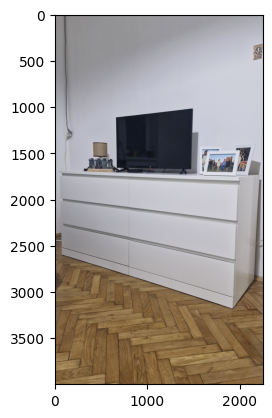

In [ ]:
img = cv2.imread('/content/sample_data/slika1.jpg')
if img is None:
    raise FileNotFoundError("file 'slika1.jpg' does not exist")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [ ]:
w = 1200
h = 800
T1 = [44, 1700, 1]
T2 = [1980, 1783, 1]
T3 = [1916, 3184, 1]
T4 = [73, 2598, 1]

In [ ]:
points = np.array([T1, T2, T3, T4])
new_points = np.array([[0, 0, 1], [w - 1, 0, 1], [w - 1, h - 1, 1], [0, h - 1, 1]])
P = DLT(points, new_points)

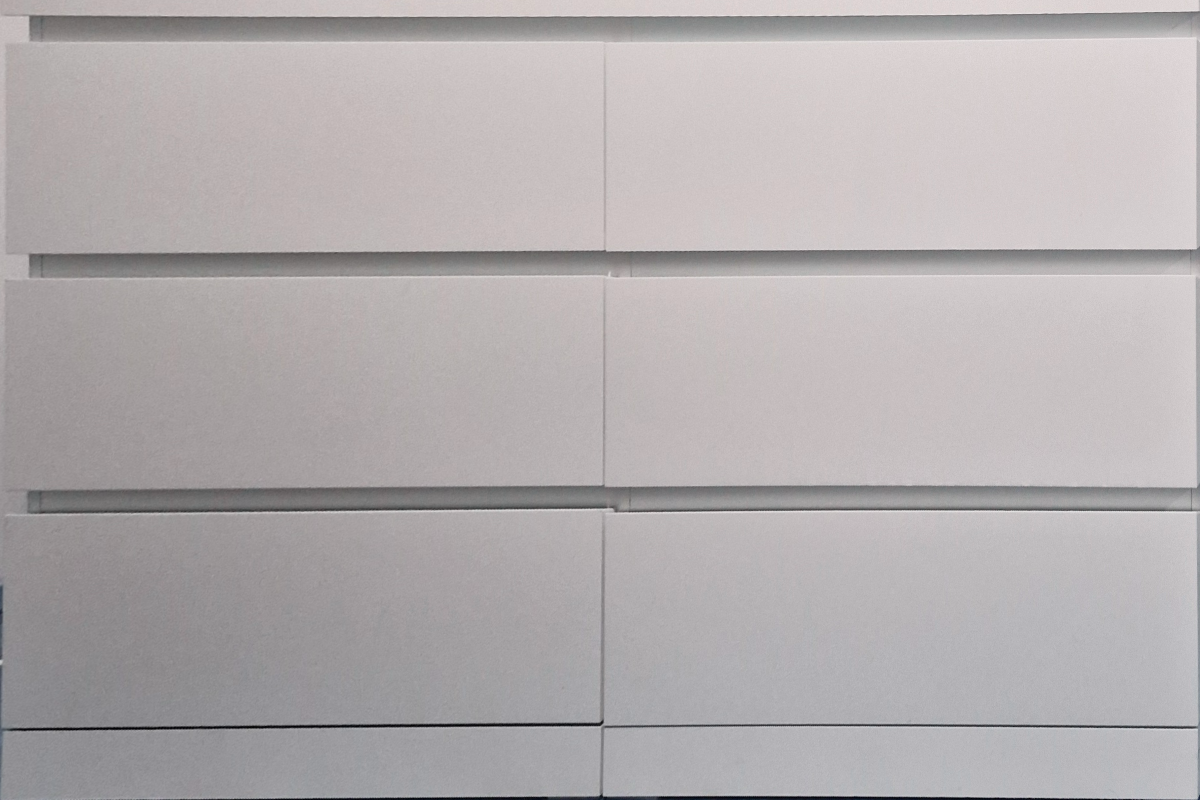

In [ ]:
from google.colab.patches import cv2_imshow

img_new = cv2.warpPerspective(img, P, (w, h))
cv2_imshow(img_new)